# PVI Landscapes on Tractable Exact Posteriors

Possibilistic Variational Inference (PVI) evaluated on four one-dimensional problems
with known exact posteriors g*_max: fits candidate possibility families (Gaussian,
Laplace, Beta), verifies the LCBO (s = -1) / UCBO (s = +1) sandwich decomposition
via the max-relative entropy D_max, checks grid resolution and domain truncation artefacts,
and evaluates order-p divergence softenings (D_p) to confirm candidate misspecification.

## Setup


In [1]:
SEED = 42
import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"SEED = {SEED}")

import os
import math
import matplotlib
import matplotlib.pyplot as plt

SAVE_FIGS = True
FIG_DIR = 'figs'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fname):
    if SAVE_FIGS:
        plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches='tight')

%matplotlib inline
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4})

from src.cbo import log_z_max, lcbo, ucbo, d_max, sandwich_check
from src.families import GaussianPoss, LaplacePoss, BetaPoss, AsymGaussianPoss
from src.cases import (
    make_bernoulli_beta,
    make_gaussian_known_var,
    make_laplace_likelihood,
    make_bimodal)


SEED = 42


## 1. Gaussian Known Variance (Sanity Check)

**Model:** $x_i \sim \mathcal{N}(\theta, \sigma^2_{\mathrm{obs}})$, $\theta \in \mathbb{R}$,
prior $\pi = \mathcal{N}(\mu_0, \sigma^2_0)$.

The conjugate possibilistic posterior is exactly Gaussian. LCBO and UCBO should
both be tightly attained at the conjugate parameters.


In [2]:
case_gv = make_gaussian_known_var(n_obs=30, mu_true=1.5, sigma_obs=1.0,
                                   mu_prior=0.0, sigma_prior=2.0)
print(f'Case: {case_gv.name}, log Z_max = {log_z_max(case_gv.ell, case_gv.log_pi).item():.4f}')

n_obs_gv = 30; sigma_obs_gv = 1.0; sigma_prior_gv = 2.0; mu_prior_gv = 0.0
x_bar = case_gv.theta_grid[case_gv.ell.argmin()].item()
sigma_post = 1.0 / np.sqrt(n_obs_gv / sigma_obs_gv**2 + 1.0 / sigma_prior_gv**2)
mu_post_exact = sigma_post**2 * (
    n_obs_gv * x_bar / sigma_obs_gv**2 + mu_prior_gv / sigma_prior_gv**2)
print(f"x_bar={x_bar:.4f}, mu_post_exact={mu_post_exact:.4f}, sigma_post={sigma_post:.4f}")


Case: gaussian_known_var, log Z_max = -0.1961
x_bar=1.2455, mu_post_exact=1.2352, sigma_post=0.1818


In [3]:
gp_gv = GaussianPoss(mu=0.0, sigma=1.0).fit(case_gv.log_g_star, case_gv.theta_grid)
print(f'Fitted: mu={gp_gv.mu:.4f}, sigma={gp_gv.sigma:.4f}')
print(f'Exact:  mu={mu_post_exact:.4f}, sigma={sigma_post:.4f}')

log_g_gv = gp_gv.log_poss(case_gv.theta_grid)


Fitted: mu=1.2455, sigma=0.1818
Exact:  mu=1.2352, sigma=0.1818


In [4]:
info_gv = sandwich_check(log_g_gv, case_gv.ell, case_gv.log_pi)
print(f'LCBO={info_gv["lcbo"].item():.4f}, log_Zmax={info_gv["log_z_max"].item():.4f}, '
      f'UCBO={info_gv["ucbo"].item():.4f}')
print(f'Dmax(g||g*)={info_gv["d_max_lower"].item():.4f}, Dmax(g*||g)={info_gv["d_max_upper"].item():.4f}')


LCBO=-0.7632, log_Zmax=-0.1961, UCBO=0.3020
Dmax(g||g*)=0.5671, Dmax(g*||g)=0.4980


In [5]:
mode_gv = case_gv.theta_grid[case_gv.log_g_star.argmax()].item()
print(f"mu_hat={gp_gv.mu:.4f}, argmax g*={mode_gv:.4f}")
print(f"mu_post_exact={mu_post_exact:.4f}, diff={abs(gp_gv.mu-mu_post_exact):.4f}")
print(f"sigma_post={sigma_post:.4f}, diff={abs(gp_gv.sigma-sigma_post):.4f}")


mu_hat=1.2455, argmax g*=1.2455
mu_post_exact=1.2352, diff=0.0103
sigma_post=0.1818, diff=0.0000


## 2. Bernoulli-Beta Case

**Model:** $x_i \sim \mathrm{Bernoulli}(\theta)$, $\theta \in (0,1)$,
prior $\pi = \mathrm{Beta}(\alpha_0, \beta_0)$.

The possibilistic posterior is a Beta possibility function with
$\alpha^* = \alpha_0 + k$, $\beta^* = \beta_0 + (n - k)$.


In [6]:
case_bb = make_bernoulli_beta(n_obs=20, p_true=0.7, alpha_prior=2.0, beta_prior=2.0)
print(f'Case: {case_bb.name}, log Z_max = {log_z_max(case_bb.ell, case_bb.log_pi).item():.4f}')

n_obs_bb = 20; alpha_prior_bb = 2.0; beta_prior_bb = 2.0
_rng = torch.Generator(); _rng.manual_seed(SEED)
_obs_bb = torch.bernoulli(torch.full((n_obs_bb,), 0.7), generator=_rng)
s = int(_obs_bb.sum().item())
alpha_star = alpha_prior_bb + s
beta_star = beta_prior_bb + (n_obs_bb - s)
theta_star = (alpha_star - 1) / (alpha_star + beta_star - 2)
print(f"s={s}, alpha*={alpha_star:.0f}, beta*={beta_star:.0f}, theta*={theta_star:.4f}")


Case: bernoulli_beta, log Z_max = -15.1582
s=11, alpha*=13, beta*=11, theta*=0.5455


In [7]:
gp_bb = GaussianPoss(mu=0.5, sigma=0.1).fit(case_bb.log_g_star, case_bb.theta_grid)
bp_bb = BetaPoss(alpha=2.0, beta=2.0).fit(case_bb.log_g_star, case_bb.theta_grid)
print(f'GaussianPoss: mu={gp_bb.mu:.4f}, sigma={gp_bb.sigma:.4f}')
print(f'BetaPoss: alpha={bp_bb.alpha:.2f}, beta={bp_bb.beta:.2f}')
print(f'Analytical: alpha*={alpha_star:.0f}, beta*={beta_star:.0f}')
print(f'  gap: d_alpha={abs(bp_bb.alpha-alpha_star):.4f}, d_beta={abs(bp_bb.beta-beta_star):.4f}')

log_g_gauss = gp_bb.log_poss(case_bb.theta_grid)
log_g_beta = bp_bb.log_poss(case_bb.theta_grid)


GaussianPoss: mu=0.5451, sigma=0.1057
BetaPoss: alpha=13.00, beta=11.00
Analytical: alpha*=13, beta*=11
  gap: d_alpha=0.0000, d_beta=0.0000


In [8]:
print(f'{"Family":<20} {"LCBO":>10} {"log Z_max":>10} {"UCBO":>10} {"D(g||g*)":>14} {"D(g*||g)":>14}')
for log_g, label in [(log_g_gauss, 'GaussianPoss'), (log_g_beta, 'BetaPoss')]:
    info = sandwich_check(log_g, case_bb.ell, case_bb.log_pi)
    lzm = info['log_z_max'].item()
    print(f'{label:<20} {info["lcbo"].item():>10.4f} {lzm:>10.4f} '
          f'{info["ucbo"].item():>10.4f} {info["d_max_lower"].item():>14.4f} '
          f'{info["d_max_upper"].item():>14.4f}')


Family                     LCBO  log Z_max       UCBO       D(g||g*)       D(g*||g)
GaussianPoss          -152.4862   -15.1582   -15.1556       137.3280         0.0026
BetaPoss               -15.1582   -15.1582   -15.1582         0.0000         0.0000


## 3. Laplace Likelihood

**Model:** $x_i \sim \mathrm{Laplace}(\theta, b)$, uniform prior.

$g^*_{\max}$ is non-smooth at the sample median. We compare GaussianPoss vs
LaplacePoss and examine the $D_{\max}$ gap difference.


In [9]:
case_lp = make_laplace_likelihood(n_obs=20, mu_true=1.0, b_obs=1.0)
print(f'Case: {case_lp.name}, log Z_max = {log_z_max(case_lp.ell, case_lp.log_pi).item():.4f}')
theta_med = case_lp.theta_grid[case_lp.ell.argmin()].item()
print(f"theta_med={theta_med:.4f} (kink of g*)")


Case: laplace_likelihood, log Z_max = -17.0948
theta_med=1.2374 (kink of g*)


GaussianPoss: mu=1.2374, sigma=0.1551
LaplacePoss:  mu=1.2374, b=0.3643


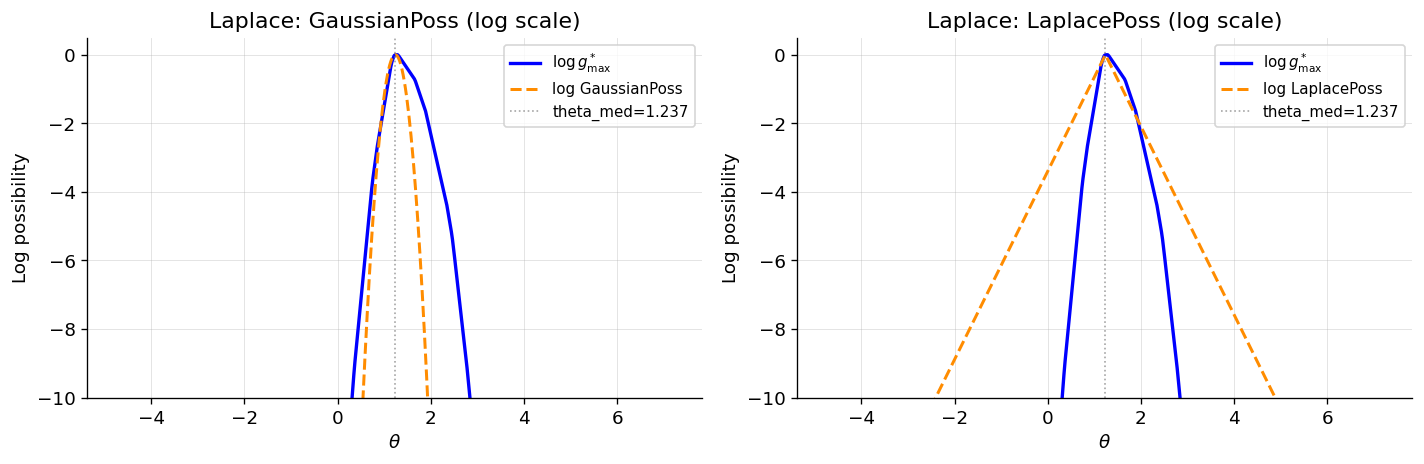

In [10]:
gp_lp = GaussianPoss(mu=1.0, sigma=1.0).fit(case_lp.log_g_star, case_lp.theta_grid)
lp_lp = LaplacePoss(mu=1.0, b=1.0).fit(case_lp.log_g_star, case_lp.theta_grid)
print(f'GaussianPoss: mu={gp_lp.mu:.4f}, sigma={gp_lp.sigma:.4f}')
print(f'LaplacePoss:  mu={lp_lp.mu:.4f}, b={lp_lp.b:.4f}')

log_g_gauss_lp = gp_lp.log_poss(case_lp.theta_grid)
log_g_laplace = lp_lp.log_poss(case_lp.theta_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, log_g, label in zip(
    axes, [log_g_gauss_lp, log_g_laplace], ['GaussianPoss', 'LaplacePoss']
):
    theta = case_lp.theta_grid.numpy()
    ax.plot(theta, case_lp.log_g_star.numpy(), 'b-', lw=2, label=r'$\log g^*_{{\max}}$')
    ax.plot(theta, log_g.numpy(), '--', color='darkorange', lw=1.8, label=f'log {label}')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('Log possibility')
    ax.set_title(f'Laplace: {label} (log scale)')
    ax.set_ylim([-10, 0.5])
    ax.axvline(theta_med, color='gray', lw=1, ls=':', alpha=0.7, label=f'theta_med={theta_med:.3f}')
    ax.legend(fontsize=9)
plt.tight_layout()
savefig('fig_laplace_posterior_logscale.png')
plt.show()


In [11]:
print(f'{"Family":<20} {"D(g||g*)":>14} {"D(g*||g)":>14} {"sum":>10}')
for log_g, label in [(log_g_gauss_lp, 'GaussianPoss'), (log_g_laplace, 'LaplacePoss')]:
    info = sandwich_check(log_g, case_lp.ell, case_lp.log_pi)
    dl = info['d_max_lower'].item()
    du = info['d_max_upper'].item()
    print(f'{label:<20} {dl:>14.4f} {du:>14.4f} {dl+du:>10.4f}')


Family                     D(g||g*)       D(g*||g)        sum
GaussianPoss                 0.3464       650.0823   650.4288
LaplacePoss                 93.8941         0.4183    94.3123


In [12]:
results = {}
for N_test in [500, 1000, 2000, 5000]:
    case_fine = make_laplace_likelihood(n_obs=20, mu_true=1.0, b_obs=1.0, N=N_test, seed=SEED)
    log_g_lap_fine = LaplacePoss(mu=lp_lp.mu, b=lp_lp.b).log_poss(case_fine.theta_grid)
    dm = d_max(log_g_lap_fine, case_fine.log_g_star).item()
    results[N_test] = dm
    print(f"N={N_test:5d}: Dmax(Lap*||g*) = {dm:.4f}")


N=  500: Dmax(Lap*||g*) = 93.8941
N= 1000: Dmax(Lap*||g*) = 93.9105
N= 2000: Dmax(Lap*||g*) = 93.9023
N= 5000: Dmax(Lap*||g*) = 93.8973


## 4. Bimodal Case

**Model:** $x_i \sim \frac{1}{2}\mathcal{N}(\theta^*, 1) + \frac{1}{2}\mathcal{N}(-\theta^*, 1)$
with $\theta^* = 2$.

The possibilistic posterior has two symmetric modes, and a single Gaussian candidate
cannot be both mode-seeking and mass-covering.

In [13]:
case_bm = make_bimodal(n_obs=10)
print(f'Case: {case_bm.name}, log Z_max = {log_z_max(case_bm.ell, case_bm.log_pi).item():.4f}')


Case: bimodal, log Z_max = -9.4045


In [14]:
gp_bm = GaussianPoss(mu=2.0, sigma=0.8)
log_g_bm = gp_bm.log_poss(case_bm.theta_grid)
info_bm = sandwich_check(log_g_bm, case_bm.ell, case_bm.log_pi)

print('GaussianPoss(mu=2.0, sigma=0.8):')
print(f'  LCBO={info_bm["lcbo"].item():.4f}, log_Zmax={info_bm["log_z_max"].item():.4f}, UCBO={info_bm["ucbo"].item():.4f}')
print(f'  Dmax(g||g*)={info_bm["d_max_lower"].item():.4f}, Dmax(g*||g)={info_bm["d_max_upper"].item():.4f}')


GaussianPoss(mu=2.0, sigma=0.8):
  LCBO=-43.4301, log_Zmax=-9.4045, UCBO=6.3974
  Dmax(g||g*)=34.0256, Dmax(g*||g)=15.8019


## Cross-Case Summary Table

For each case x family: LCBO, UCBO, $D_{\max}(g\|g^*)$, $D_{\max}(g^*\|g)$.


In [15]:
print(f"SEED={SEED}")
print(f"Case 1: x_bar={x_bar:.4f}, mu_post_exact={mu_post_exact:.4f}, sigma_post={sigma_post:.4f}")
print(f"Case 2: s={s}, alpha*={alpha_star:.0f}, beta*={beta_star:.0f}, theta*={theta_star:.4f}")
print(f"Case 3: theta_med={theta_med:.4f}")
print()

cases_dict = {
    'bernoulli_beta': case_bb,
    'gaussian_known_var': case_gv,
    'laplace_likelihood': case_lp,
    'bimodal': case_bm}

combos = [
    ('bernoulli_beta', gp_bb),
    ('bernoulli_beta', bp_bb),
    ('gaussian_known_var', gp_gv),
    ('gaussian_known_var',
     AsymGaussianPoss(mu=0.0, sigma_l=1.0, sigma_r=1.0).fit(
         case_gv.log_g_star, case_gv.theta_grid)),
    ('laplace_likelihood', gp_lp),
    ('laplace_likelihood', lp_lp),
    ('bimodal', GaussianPoss(mu=2.0, sigma=0.8)),
    ('bimodal',
     AsymGaussianPoss(mu=2.0, sigma_l=0.8, sigma_r=0.8).fit(
         case_bm.log_g_star, case_bm.theta_grid))]

header = f'{"Case":<22} {"Family":<20} {"log_Zmax":>10} {"LCBO":>10} {"UCBO":>10} {"D(g||g*)":>10} {"D(g*||g)":>10}'
print(header)
print('-' * len(header))
for case_name, fam in combos:
    case = cases_dict[case_name]
    log_g = fam.log_poss(case.theta_grid)
    info = sandwich_check(log_g, case.ell, case.log_pi)
    print(f'{case_name:<22} {type(fam).__name__:<20} '
          f'{info["log_z_max"].item():>10.4f} {info["lcbo"].item():>10.4f} '
          f'{info["ucbo"].item():>10.4f} {info["d_max_lower"].item():>10.4f} '
          f'{info["d_max_upper"].item():>10.4f}')


SEED=42
Case 1: x_bar=1.2455, mu_post_exact=1.2352, sigma_post=0.1818
Case 2: s=11, alpha*=13, beta*=11, theta*=0.5455
Case 3: theta_med=1.2374

Case                   Family                 log_Zmax       LCBO       UCBO   D(g||g*)   D(g*||g)
--------------------------------------------------------------------------------------------------
bernoulli_beta         GaussianPoss           -15.1582  -152.4862   -15.1556   137.3280     0.0026
bernoulli_beta         BetaPoss               -15.1582   -15.1582   -15.1582     0.0000     0.0000
gaussian_known_var     GaussianPoss            -0.1961    -0.7632     0.3020     0.5671     0.4980
gaussian_known_var     AsymGaussianPoss        -0.1961    -0.7634     0.3019     0.5674     0.4979
laplace_likelihood     GaussianPoss           -17.0948   -17.4412   632.9875     0.3464   650.0823
laplace_likelihood     LaplacePoss            -17.0948  -110.9888   -16.6765    93.8941     0.4183
bimodal                GaussianPoss            -9.4045   -43.43

In [16]:
import csv
import os

os.makedirs('results', exist_ok=True)

rows = []
for case_name, fam in combos:
    case = cases_dict[case_name]
    log_g = fam.log_poss(case.theta_grid)
    info = sandwich_check(log_g, case.ell, case.log_pi)
    rows.append({
        'case': case_name,
        'family': type(fam).__name__,
        'log_z_max': round(info['log_z_max'].item(), 4),
        'lcbo': round(info['lcbo'].item(), 4),
        'ucbo': round(info['ucbo'].item(), 4),
        'd_max_lower': round(info['d_max_lower'].item(), 4),
        'd_max_upper': round(info['d_max_upper'].item(), 4)})

with open('results/summary_metrics.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print('saved results/summary_metrics.csv')


saved results/summary_metrics.csv


## Experiment: does a softer divergence close the gap?

Possibilistic order-$p$ divergence on the grid:

$$D_p(g \| f) = \frac{1}{p} \log \sum_\theta \exp\big(p \, (\log g(\theta) - \log f(\theta))\big), \quad f(\theta) > 0$$

Softens the hard sup used by $D_{\max}$ and recovers it exactly as $p \to \infty$.
Reuses the already-fitted GaussianPoss candidates and exact $g^*_{\max}$ from above.


In [17]:
def d_p(log_g, log_f, p, neg_inf_thresh=-1e29):
    """Order-p divergence: (1/p) log sum exp(p*(log_g-log_f)) on {f>0}."""
    in_support = log_f > neg_inf_thresh
    diff = log_g[in_support] - log_f[in_support]
    return (torch.logsumexp(p * diff, dim=0) / p).item()

P_VALUES = [1.0, 2.0, 5.0, 10.0, 50.0]

xp_combos = [
    ('bernoulli_beta', 'GaussianPoss', case_bb, log_g_gauss),
    ('laplace_likelihood', 'GaussianPoss', case_lp, log_g_gauss_lp),
    ('gaussian_known_var', 'GaussianPoss', case_gv, log_g_gv),
    ('bimodal', 'GaussianPoss', case_bm, log_g_bm)]


In [18]:
import pandas as pd

dp_rows = []
for case_name, fam_name, case, log_g in xp_combos:
    dmax_lower_ref = d_max(log_g, case.log_g_star).item()
    dmax_upper_ref = d_max(case.log_g_star, log_g).item()
    for p in P_VALUES:
        dp_rows.append({
            'case': case_name,
            'family': fam_name,
            'p': p,
            'D_p(g||g*)': round(d_p(log_g, case.log_g_star, p), 4),
            'D_p(g*||g)': round(d_p(case.log_g_star, log_g, p), 4),
            'D_max(g||g*)_ref': round(dmax_lower_ref, 4),
            'D_max(g*||g)_ref': round(dmax_upper_ref, 4)})

dp_df = pd.DataFrame(dp_rows)
dp_df


,case,family,p,D_p(g||g*),D_p(g*||g),D_max(g||g*)_ref,D_max(g*||g)_ref
0,bernoulli_beta,GaussianPoss,1.0,137.3280,5.6402,137.3280,0.0026
1,bernoulli_beta,GaussianPoss,2.0,137.3280,2.7512,137.3280,0.0026
2,bernoulli_beta,GaussianPoss,5.0,137.3280,1.0639,137.3280,0.0026
3,bernoulli_beta,GaussianPoss,10.0,137.3280,0.5186,137.3280,0.0026
4,bernoulli_beta,GaussianPoss,50.0,137.3280,0.0987,137.3280,0.0026
5,laplace_likelihood,GaussianPoss,1.0,3.4409,650.0865,0.3464,650.0823
6,laplace_likelihood,GaussianPoss,2.0,1.7040,650.0823,0.3464,650.0823
7,laplace_likelihood,GaussianPoss,5.0,0.7721,650.0823,0.3464,650.0823
8,laplace_likelihood,GaussianPoss,10.0,0.5138,650.0823,0.3464,650.0823
9,laplace_likelihood,GaussianPoss,50.0,0.3630,650.0823,0.3464,650.0823


## Domain truncation and numerical precision

Sensitivity checks for the effects discussed above: growing the truncated domain on
$\Theta = \mathbb{R}$ cases (1 and 4), and float32 vs float64 for the Beta candidate's
$D_{\max}$ (case 2).


In [19]:
rng_gv = torch.Generator()
rng_gv.manual_seed(SEED)
obs_gv_full = 1.5 + 1.0 * torch.randn(30, generator=rng_gv)
x_bar_true_gv = obs_gv_full.mean().item()

sigma_residual = gp_gv.sigma - sigma_post
print(f'gp_gv.sigma = {gp_gv.sigma:.8f}  sigma_post = {sigma_post:.8f}  residual = {sigma_residual:.2e}')

margin0_gv = 5.0 * max(1.0 / (30 ** 0.5), 2.0)
lo_base_gv, hi_base_gv = 0.0 - margin0_gv, 1.5 + margin0_gv
density_gv = 500 / (hi_base_gv - lo_base_gv)
for factor in [1, 2, 4]:
    margin = factor * margin0_gv
    lo, hi = 0.0 - margin, 1.5 + margin
    N = int(round(density_gv * (hi - lo)))
    theta_grid = torch.linspace(lo, hi, N)
    ell = (30 / 2.0) * (theta_grid - x_bar_true_gv) ** 2
    log_pi = -0.5 * (theta_grid / 2.0) ** 2
    log_g = gp_gv.log_poss(theta_grid)
    l = lcbo(log_g, ell, log_pi).item()
    u = ucbo(log_g, ell, log_pi).item()
    print(f'  {factor}x [{lo:.1f},{hi:.1f}] N={N}: LCBO={l:.4f}  UCBO={u:.4f}')


gp_gv.sigma = 0.18181869  sigma_post = 0.18181818  residual = 5.09e-07
  1x [-10.0,11.5] N=500: LCBO=-0.7632  UCBO=0.3020
  2x [-20.0,21.5] N=965: LCBO=-1.2925  UCBO=0.7632
  4x [-40.0,41.5] N=1895: LCBO=-2.3867  UCBO=1.6504


In [20]:
info_beta_bb = sandwich_check(log_g_beta, case_bb.ell, case_bb.log_pi)
print(f'Beta candidate (float32, as fitted above): '
      f'Dmax(g||g*)={info_beta_bb["d_max_lower"].item():.3e}  '
      f'Dmax(g*||g)={info_beta_bb["d_max_upper"].item():.3e}')

theta64 = case_bb.theta_grid.double()
log_g_star64 = case_bb.log_g_star.double()
ell64 = case_bb.ell.double()
log_pi64 = case_bb.log_pi.double()
eps = 1e-8
th64 = theta64.clamp(eps, 1 - eps)
X64 = torch.stack([torch.ones(len(theta64), dtype=torch.float64), th64.log(), (1 - th64).log()], dim=1)
coeffs64 = torch.linalg.solve(X64.t() @ X64, X64.t() @ log_g_star64)
alpha64, beta64 = coeffs64[1].item() + 1, coeffs64[2].item() + 1
log_g_beta64 = (alpha64 - 1) * th64.log() + (beta64 - 1) * (1 - th64).log()
log_g_beta64 = log_g_beta64 - log_g_beta64.max()
info_beta64 = sandwich_check(log_g_beta64, ell64, log_pi64)
print(f'Beta candidate (float64): alpha={alpha64:.6f} beta={beta64:.6f}  '
      f'Dmax(g||g*)={info_beta64["d_max_lower"].item():.3e}  '
      f'Dmax(g*||g)={info_beta64["d_max_upper"].item():.3e}')


Beta candidate (float32, as fitted above): Dmax(g||g*)=3.052e-05  Dmax(g*||g)=2.289e-05
Beta candidate (float64): alpha=13.000000 beta=11.000000  Dmax(g||g*)=4.516e-06  Dmax(g*||g)=4.958e-06


In [21]:
gp_bm_fit = GaussianPoss(mu=2.0, sigma=0.8).fit(case_bm.log_g_star, case_bm.theta_grid)
log_g_fit = gp_bm_fit.log_poss(case_bm.theta_grid)
info_fit = sandwich_check(log_g_fit, case_bm.ell, case_bm.log_pi)
print(f'plain GaussianPoss.fit(): mu={gp_bm_fit.mu:.4f} sigma={gp_bm_fit.sigma:.4f}')
print(f'  LCBO={info_fit["lcbo"].item():.4f} UCBO={info_fit["ucbo"].item():.4f}')

asym_bm = AsymGaussianPoss(mu=2.0, sigma_l=0.8, sigma_r=0.8).fit(case_bm.log_g_star, case_bm.theta_grid)
log_g_asym = asym_bm.log_poss(case_bm.theta_grid)
info_asym = sandwich_check(log_g_asym, case_bm.ell, case_bm.log_pi)
print(f'AsymGaussianPoss.fit(): mu={asym_bm.mu:.4f} sigma_l={asym_bm.sigma_l:.4f} sigma_r={asym_bm.sigma_r:.4f}')
print(f'  LCBO={info_asym["lcbo"].item():.4f} UCBO={info_asym["ucbo"].item():.4f}')

n_obs_bm = 10
THETA_STAR = 2.0
rng_bm = torch.Generator()
rng_bm.manual_seed(SEED)
which_bm = torch.bernoulli(torch.full((n_obs_bm,), 0.5), generator=rng_bm)
obs_bm = torch.where(which_bm.bool(), THETA_STAR + torch.randn(n_obs_bm, generator=rng_bm),
                      -THETA_STAR + torch.randn(n_obs_bm, generator=rng_bm))

def build_ell_bm(theta_grid, obs):
    log_p_plus = -0.5 * (obs.unsqueeze(0) - theta_grid.unsqueeze(1)) ** 2
    log_p_minus = -0.5 * (obs.unsqueeze(0) + theta_grid.unsqueeze(1)) ** 2
    log_mix = torch.stack([log_p_plus, log_p_minus], dim=0).logsumexp(dim=0) - math.log(2)
    return -log_mix.sum(dim=1)

print(f'sanity: rebuilt ell max abs diff vs case_bm.ell = '
      f'{(build_ell_bm(case_bm.theta_grid, obs_bm) - case_bm.ell).abs().max().item():.2e}')

for factor, lo, hi, N in [(1, -5.0, 5.0, 500), (2, -10.0, 10.0, 1000), (4, -20.0, 20.0, 2000)]:
    theta_grid = torch.linspace(lo, hi, N)
    ell = build_ell_bm(theta_grid, obs_bm)
    log_pi = torch.zeros(N)
    log_g = gp_bm_fit.log_poss(theta_grid)
    l = lcbo(log_g, ell, log_pi).item()
    u = ucbo(log_g, ell, log_pi).item()
    print(f'  {factor}x [{lo:.0f},{hi:.0f}]: LCBO={l:.4f}  UCBO={u:.4f}')

fam_rounded = GaussianPoss(mu=-2.1343, sigma=0.3182)
for factor, lo, hi, N in [(1, -5.0, 5.0, 500), (2, -10.0, 10.0, 1000), (4, -20.0, 20.0, 2000)]:
    theta_grid = torch.linspace(lo, hi, N)
    ell = build_ell_bm(theta_grid, obs_bm)
    log_pi = torch.zeros(N)
    log_g = fam_rounded.log_poss(theta_grid)
    l = lcbo(log_g, ell, log_pi).item()
    u = ucbo(log_g, ell, log_pi).item()
    print(f'  {factor}x [{lo:.0f},{hi:.0f}]: LCBO={l:.4f}  UCBO={u:.4f}')


plain GaussianPoss.fit(): mu=-2.1343 sigma=0.3182
  LCBO=-9.9174 UCBO=200.8167
AsymGaussianPoss.fit(): mu=-2.1343 sigma_l=0.3184 sigma_r=0.3185
  LCBO=-9.9466 UCBO=200.3333
sanity: rebuilt ell max abs diff vs case_bm.ell = 0.00e+00
  1x [-5,5]: LCBO=-9.9174  UCBO=200.8167
  2x [-10,10]: LCBO=-13.1785  UCBO=408.2898
  4x [-20,20]: LCBO=-29.1597  UCBO=813.7761
  1x [-5,5]: LCBO=-9.9076  UCBO=200.8849
  2x [-10,10]: LCBO=-13.1007  UCBO=408.4843
  4x [-20,20]: LCBO=-28.7517  UCBO=814.4187


In [22]:
for factor, lo, hi, N in [(1, -5.0, 5.0, 500), (2, -10.0, 10.0, 1000), (4, -20.0, 20.0, 2000)]:
    theta_grid = torch.linspace(lo, hi, N)
    ell = build_ell_bm(theta_grid, obs_bm)
    log_pi = torch.zeros(N)
    log_g = gp_bm.log_poss(theta_grid)
    l = lcbo(log_g, ell, log_pi).item()
    u = ucbo(log_g, ell, log_pi).item()
    print(f'  {factor}x [{lo:.0f},{hi:.0f}]: LCBO={l:.4f}  UCBO={u:.4f}')


  1x [-5,5]: LCBO=-43.4301  UCBO=6.3974
  2x [-10,10]: LCBO=-268.6241  UCBO=6.3972
  4x [-20,20]: LCBO=-1351.8208  UCBO=6.3972


## Grid domain summary and boundary locations

Domain bounds, $N$, and grid spacing $\delta$ per case, and the exact grid location of the
worst-case $\theta$ for LCBO/UCBO in case 1.


In [23]:
print(f'{"case":<20} {"min":>10} {"max":>10} {"N":>6} {"delta":>10}')
for case in [case_bb, case_gv, case_lp, case_bm]:
    lo = case.theta_grid.min().item()
    hi = case.theta_grid.max().item()
    N = len(case.theta_grid)
    delta = (hi - lo) / (N - 1)
    print(f'{case.name:<20} {lo:>10.4f} {hi:>10.4f} {N:>6d} {delta:>10.4f}')


case                        min        max      N      delta
bernoulli_beta           0.0000     1.0000    500     0.0020
gaussian_known_var     -10.0000    11.5000    500     0.0431
laplace_likelihood      -4.7746     7.2254    500     0.0240
bimodal                 -5.0000     5.0000    500     0.0200


In [24]:
obj_gv = -case_gv.ell - log_g_gv + case_gv.log_pi
worst_idx_l = obj_gv.argmin()
worst_idx_u = obj_gv.argmax()
theta_l = case_gv.theta_grid[worst_idx_l].item()
theta_u = case_gv.theta_grid[worst_idx_u].item()
lo_gv = case_gv.theta_grid.min().item()
hi_gv = case_gv.theta_grid.max().item()
print(f'LCBO argmin: theta={theta_l:.4f}  obj={obj_gv[worst_idx_l].item():.4f}  '
      f'at grid min ({lo_gv})? {abs(theta_l - lo_gv) < 1e-6}')
print(f'UCBO argmax: theta={theta_u:.4f}  obj={obj_gv[worst_idx_u].item():.4f}  '
      f'at grid max ({hi_gv})? {abs(theta_u - hi_gv) < 1e-6}')


LCBO argmin: theta=-10.0000  obj=-0.7632  at grid min (-10.0)? True
UCBO argmax: theta=11.5000  obj=0.3020  at grid max (11.5)? True
